In [6]:
with open("./EvaluationGradientBasedImportance.txt","r") as file:
    text = file.read()
    
len(text)

612644

In [7]:
import re

entries = re.split(r'-{20,}', text)
len(entries)

245

In [22]:
# Extract prediction information
data = []
for entry in entries:
    original_pred_match = re.search(r"Model original prediction:\s+(\d+)\s+([\d.]+)", entry)
    without_topk_match = re.search(r"Model w/out top-k:\s+(\d+)\s+([\d.]+)", entry)
    
    if original_pred_match and without_topk_match:
        original_label, original_conf = original_pred_match.groups()
        no_topk_label, no_topk_conf = without_topk_match.groups()
        data.append({
            "Original Prediction": int(original_label),
            "Original Confidence": float(original_conf),
            "Without Top-K Prediction": int(no_topk_label),
            "Without Top-K Confidence": float(no_topk_conf)
        })

In [23]:
import pandas as pd
df = pd.DataFrame(data)

In [24]:
df["Change in Confidence"] = df["Original Confidence"] - df["Without Top-K Confidence"]

In [25]:
df_0 = df[df["Original Prediction"] == 0]
df_1 = df[df["Original Prediction"] == 1]
len(df_0), len(df_1)

(131, 112)

In [35]:
df_0_same_label = df_0[df_0["Without Top-K Prediction"] == df_0["Original Prediction"]]
len(df_0_same_label), df_0_same_label["Change in Confidence"].min(), df_0_same_label["Change in Confidence"].max(), df_0_same_label["Change in Confidence"].mean()

(131, 0.012448370456695557, 0.4857751131057739, 0.08973825250873128)

In [36]:
import matplotlib.pyplot as plt

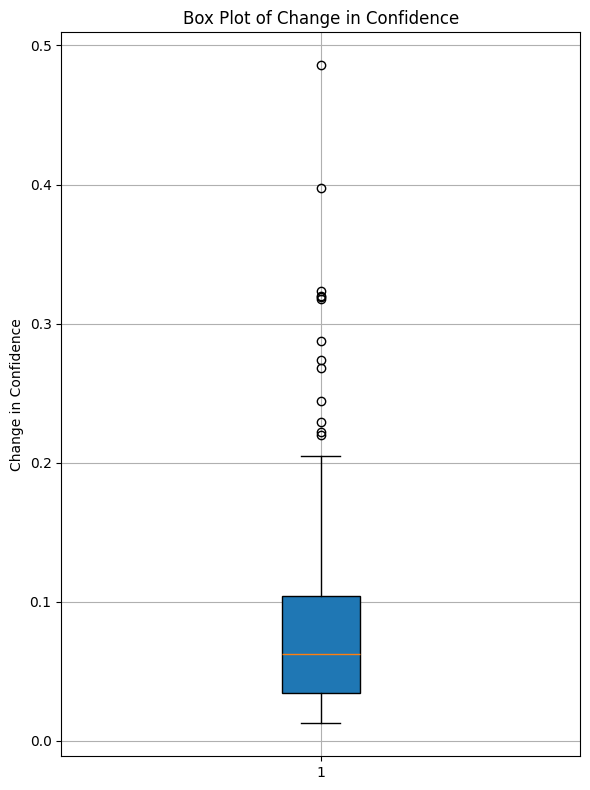

In [37]:
plt.figure(figsize=(6, 8))
plt.boxplot(df_0_same_label["Change in Confidence"], vert=True, patch_artist=True)
plt.title("Box Plot of Change in Confidence")
plt.ylabel("Change in Confidence")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
df_0_same_label.head(10)

,Original Prediction,Original Confidence,Without Top-K Prediction,Without Top-K Confidence,Change in Confidence
1,0,0.994547,0,0.931000,0.063547
2,0,0.992974,0,0.789890,0.203083
4,0,0.994446,0,0.877961,0.116486
5,0,0.993785,0,0.962876,0.030908
6,0,0.994291,0,0.938331,0.055959
7,0,0.994435,0,0.974255,0.020180
9,0,0.993737,0,0.976632,0.017105
10,0,0.993995,0,0.893711,0.100284
12,0,0.994309,0,0.891530,0.102779
14,0,0.993411,0,0.938330,0.055081


In [32]:
df_0_changed_label = df_0[df_0["Without Top-K Prediction"] != df_0["Original Prediction"]]
len(df_0_changed_label), df_0_changed_label["Change in Confidence"].mean()

(0, nan)

In [33]:
df_1_same_label = df_1[df_1["Without Top-K Prediction"] == df_1["Original Prediction"]]
len(df_1_same_label), df_1_same_label["Change in Confidence"].mean()

(46, 0.23888419115025064)

In [30]:
df_1_changed_label = df_1[df_1["Without Top-K Prediction"] != df_1["Original Prediction"]]
len(df_1_changed_label), df_1_changed_label["Change in Confidence"].mean()

(66, 0.21746049776221765)